In [1]:
import neuralforecast as nf
from neuralforecast import NeuralForecast
import logging
logging.getLogger('pytorch_lightning').setLevel(logging.ERROR)
from neuralforecast.losses.pytorch import MAE
from neuralforecast.auto import AutoGRU, AutoTCN, AutoFEDformer, AutoPatchTST
from neuralforecast.models import GRU, TCN, FEDformer, PatchTST
import pandas as pd
import numpy as np
import inspect

from sktime.performance_metrics.forecasting import (
    mean_absolute_scaled_error,
    mean_absolute_error,
    mean_absolute_percentage_error,
)

import matplotlib.pyplot as plt
from sktime.utils.plotting import plot_series

In [2]:
from typing import Optional


def wide_to_long_df(df: pd.DataFrame) -> pd.DataFrame:
    kursy = df[['USD_EUR']]
    kursy = kursy.rename(columns={"USD_EUR": "exo", "DATE": "ds"})
    df_copy = df.drop(columns=['USD_EUR']).copy()
    df_long = pd.melt(df_copy, ignore_index=False).reset_index(names="ds")
    df_long = df_long.rename(columns={"variable": "unique_id", "value": "y"})
    df_long = df_long.merge(kursy, left_on='ds', right_index=True, how='left')

    return df_long


def long_to_wide_df(df: pd.DataFrame, values_col: Optional[str] = None) -> pd.DataFrame:
    if "unique_id" not in df.columns:
        df = df.reset_index(names="unique_id")

    values_col = values_col if values_col else df.columns[-1]
    df = pd.pivot(df, columns="unique_id", index="ds", values=values_col)
    return df

In [3]:
df_stocks = pd.read_csv('portfolio_data.csv')
df_btc = df_stocks[['Date','BTC']].copy()
df_btc.index = pd.to_datetime(df_btc['Date'])
df_btc = df_btc.drop(columns=['Date'])

date_range_btc = pd.date_range(start=df_btc.index.min(),
                                end=df_btc.index.max(),
                                freq='D')
df_btc = df_btc.reindex(date_range_btc, method='ffill')

df_kurs = pd.read_csv('USD-EUR.csv')
df_kurs = df_kurs[['Date','Price']].copy()
df_kurs = df_kurs.sort_index(ascending=False)
df_kurs.index = pd.to_datetime(df_kurs['Date'])
df_kurs = df_kurs.drop(columns=['Date'])

date_range_kurs = pd.date_range(start=df_kurs.index.min(),
                                 end=df_kurs.index.max(),
                                 freq='D')
df_kurs = df_kurs.reindex(date_range_kurs, method='ffill')

df = df_btc.join(df_kurs, how='inner')
df.rename(columns={'BTC':'BTC_Price','Price':'USD_EUR'}, inplace=True)

df_kurs_full = df_kurs.copy()
extended_end = df.index.max() + pd.Timedelta(days=365)  # Add buffer for future forecasts
extended_range = pd.date_range(start=df_kurs_full.index.min(),
                                end=extended_end,
                                freq='D')
df_kurs_full = df_kurs_full.reindex(extended_range, method='ffill')

In [4]:
df_train = df.loc[df.index < '2019-01-01']
df_test = df.loc[df.index >= '2019-01-01']

In [5]:
def find_best_params(model, df_train: pd.DataFrame) -> dict:
    print("Finding best hyperparameters...")
    data_train = wide_to_long_df(df_train)
    data_train['y'].loc[data_train['y'].isna()==True] = 0

    model.fit(data_train)

    best_model = nf_auto.models[0]

    all_possible_params = [
        # Common params
        'input_size', 'learning_rate', 'max_steps', 'batch_size',
        'windows_batch_size', 'scaler_type', 'hist_exog_list',

        # RNN-based (GRU, LSTM, RNN)
        'encoder_hidden_size', 'encoder_n_layers', 'encoder_dropout',
        'context_size', 'decoder_hidden_size', 'decoder_layers',

        # TCN-specific
        'kernel_size', 'dilations', 'hidden_size',

        # Transformer-based (PatchTST, FEDformer, etc.)
        'patch_len', 'stride', 'n_heads', 'encoder_layers',
        'dropout', 'fc_dropout', 'head_dropout', 'attn_dropout',
        'linear_hidden_size', 'revin',

        # Other
        'val_check_steps', 'early_stop_patience_steps'
        ]

    best_config = {}
    for param in all_possible_params:
        if hasattr(best_model, param):
            value = getattr(best_model, param)
            best_config[param] = value
            print(f"  {param}: {value}")

    if not best_config:
        print("\nWarning: No parameters extracted via attributes.")
        print("Available attributes:", [a for a in dir(best_model) if not a.startswith('_')][:20])

    return best_config


def evaluate_model_rolling(
    model_class,
    best_config: dict,
    df_train: pd.DataFrame,
    df_test: pd.DataFrame,
    df_kurs: pd.DataFrame,
    h=14
) -> pd.DataFrame:

    current_train = df_train.copy()
    all_forecasts = []

    n_test = len(df_test)
    n_windows = (n_test + h - 1) // h

    valid_params = set(inspect.signature(model_class.__init__).parameters.keys())
    valid_params.discard('self')

    filtered_config = {k: v for k, v in best_config.items()
                      if k in valid_params}

    print(f"Using {len(filtered_config)} parameters: {list(filtered_config.keys())}")

    for window in range(n_windows):
        print(f"Window {window + 1}/{n_windows}")

        data_train = wide_to_long_df(current_train)
        data_train['y'].loc[data_train['y'].isna()==True] = 0

        model = model_class(h=h, loss=MAE(), verbose=False, **filtered_config)

        nf_model = NeuralForecast(models=[model], freq="D")
        nf_model.fit(data_train)

        last_train_date = current_train.index[-1]
        future_dates = pd.date_range(
            start=last_train_date + pd.Timedelta(days=1),
            periods=h,
            freq='D'
        )

        future_exog = df_kurs.reindex(future_dates, method='ffill')['Price'].values

        futr_df = pd.DataFrame({
            'ds': future_dates,
            'unique_id': 'BTC_Price',
            'exo': future_exog
        })

        forecasts = nf_model.predict(futr_df=futr_df)
        forecasts_wide = long_to_wide_df(forecasts)

        all_forecasts.append(forecasts_wide)

        next_train_dates = future_dates[:min(h, len(df_test) - window * h)]

        if len(next_train_dates) > 0:
            new_train_data = df_test.loc[next_train_dates]
            current_train = pd.concat([current_train, new_train_data])

    all_forecasts_df = pd.concat(all_forecasts)
    all_forecasts_df = all_forecasts_df[:len(df_test)]

    mae = mean_absolute_error(
        df_test['BTC_Price'][:len(all_forecasts_df)],
        all_forecasts_df['BTC_Price']
    )
    mase = mean_absolute_scaled_error(
        df_test['BTC_Price'][:len(all_forecasts_df)],
        all_forecasts_df['BTC_Price'],
        y_train=df_train['BTC_Price']
    )

    print(f"\nFinal Results:")
    print(f"MAE: {mae:.2f}")
    print(f"MASE: {mase:.2f}")

    return all_forecasts_df

In [6]:
h=14

def config():
    return {
        "hist_exog_list": ['exo']  # Historic exogenous
    }

model = AutoGRU(
    h=h,
    loss=MAE(),
    num_samples=20,
    verbose=False,
    config=config()
)

nf_auto = NeuralForecast(
    models=[model],
    freq="D"
    
)
best_params = find_best_params(nf_auto, df_train=df_train)

print("\nBest params:", best_params)

print("\nGRU rolling forecaster 14 days horizon:")

gru_forecast = evaluate_model_rolling(
    model_class=GRU,
    best_config=best_params,
    df_train=df_train,
    df_test=df_test,
    df_kurs=df_kurs_full,
    h=h
)

(pid=gcs_server) [2026-01-23 00:44:21,339 E 12276 19288] (gcs_server.exe) gcs_server.cc:303: Failed to establish connection to the event+metrics exporter agent. Events and metrics will not be exported. Exporter agent status: RpcError: Running out of retries to initialize the metrics agent. rpc_code: 14
(raylet) [2026-01-23 00:44:28,033 E 21736 19028] (raylet.exe) main.cc:1032: Failed to establish connection to the metrics exporter agent. Metrics will not be exported. Exporter agent status: RpcError: Running out of retries to initialize the metrics agent. rpc_code: 14
(_train_tune pid=4960) C:\Users\Ania\PycharmProjects\StockPrediction\.venv\Lib\site-packages\ray\tune\integration\pytorch_lightning.py:198: `ray.tune.integration.pytorch_lightning.TuneReportCallback` is deprecated. Use `ray.tune.integration.pytorch_lightning.TuneReportCheckpointCallback` instead.
(_train_tune pid=4960) C:\Users\Ania\PycharmProjects\StockPrediction\.venv\Lib\site-packages\neuralforecast\common\_base_model.p

Sanity Checking: |          | 0/? [00:00<?, ?it/s]
Epoch 99: 100%|██████████| 1/1 [00:00<00:00, 93.24it/s, v_num=0, train_loss_step=3.050, train_loss_epoch=2.750] 
Validation: |          | 0/? [00:00<?, ?it/s]
Validation: |          | 0/? [00:00<?, ?it/s]
Validation DataLoader 0: 100%|██████████| 1/1 [00:00<00:00, 97.39it/s]
(_train_tune pid=4960) 
Epoch 199: 100%|██████████| 1/1 [00:00<00:00, 26.46it/s, v_num=0, train_loss_step=2.540, train_loss_epoch=1.800, valid_loss=231.0]
Validation: |          | 0/? [00:00<?, ?it/s]
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 299: 100%|██████████| 1/1 [00:00<00:00, 32.22it/s, v_num=0, train_loss_step=1.480, train_loss_epoch=1.540, valid_loss=1.47e+3]
Validation: |          | 0/? [00:00<?, ?it/s]
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 399: 100%|██████████| 1/1 [00:00<00:00, 49.59it/s, v_num=0, train_loss_step=1.210, train_loss_epoch=1.100, valid_loss=1.84e+3]
Validation: |          | 0/? [00:00<?, ?it/s]
Validation: |         

(_train_tune pid=4960) `Trainer.fit` stopped: `max_steps=1000` reached.


Epoch 999: 100%|██████████| 1/1 [00:00<00:00, 47.17it/s, v_num=0, train_loss_step=0.426, train_loss_epoch=0.429, valid_loss=1.97e+3]
Validation: |          | 0/? [00:00<?, ?it/s]
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 999: 100%|██████████| 1/1 [00:00<00:00, 20.32it/s, v_num=0, train_loss_step=0.426, train_loss_epoch=0.426, valid_loss=1.38e+3]


(_train_tune pid=3412) C:\Users\Ania\PycharmProjects\StockPrediction\.venv\Lib\site-packages\ray\tune\integration\pytorch_lightning.py:198: `ray.tune.integration.pytorch_lightning.TuneReportCallback` is deprecated. Use `ray.tune.integration.pytorch_lightning.TuneReportCheckpointCallback` instead.
(_train_tune pid=3412) C:\Users\Ania\PycharmProjects\StockPrediction\.venv\Lib\site-packages\neuralforecast\common\_base_model.py:151: UserWarning: Input size too small. Automatically setting input size to 3 * horizon = 42
(_train_tune pid=3412)   warnings.warn(
(_train_tune pid=3412) Seed set to 1
(_train_tune pid=3412) GPU available: True (cuda), used: True
(_train_tune pid=3412) TPU available: False, using: 0 TPU cores
(_train_tune pid=3412) You are using a CUDA device ('NVIDIA GeForce RTX 4050 Laptop GPU') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, 

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

C:\Users\Ania\AppData\Local\Temp\ipykernel_2628\2672769059.py:72: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  data_train['y'].loc[data_train['y'].isna()==True] = 0
C:\Users\Ania\AppData\Local\Temp\ipykernel_2628\2672769059.py:72: SettingWi

  hist_exog_list: ['exo']
  early_stop_patience_steps: -1

Best params: {'hist_exog_list': ['exo'], 'early_stop_patience_steps': -1}

GRU rolling forecaster 14 days horizon:
Using 2 parameters: ['hist_exog_list', 'early_stop_patience_steps']
Window 1/10


TypeError: Trainer.__init__() got an unexpected keyword argument 'verbose'

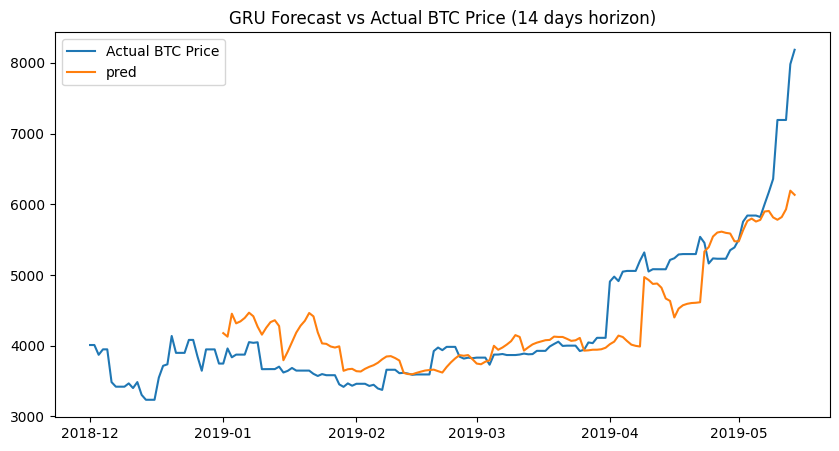

In [46]:
fig = plt.figure(figsize=(10,5))
df_part = df.loc[(df.index >= '2018-12-01')]
plt.plot(df_part.index,df_part['BTC_Price'], label='Actual BTC Price')
plt.plot(gru_forecast.index,gru_forecast, label='pred')
plt.legend()
plt.title('GRU Forecast vs Actual BTC Price (14 days horizon)')
plt.show()

In [47]:
h=14

def config():
    return {
        "hist_exog_list": ['exo']  # Historic exogenous
    }

model = AutoTCN(
    h=h,
    loss=MAE(),
    num_samples=20,
    verbose=False,
    config=config()
)

nf_auto = NeuralForecast(
    models=[model],
    freq="D"
    
)

best_params = find_best_params(nf_auto, df_train=df_train)

print("\nBest params:", best_params)

print("\nTCN rolling forecaster 14 days horizon:")

tcn_forecast = evaluate_model_rolling(
    model_class=TCN,
    best_config=best_params,
    df_train=df_train,
    df_test=df_test,
    df_kurs=df_kurs_full,
    h=h
)


(_train_tune pid=21256) C:\Users\Ania\PycharmProjects\StockPrediction\.venv\Lib\site-packages\ray\tune\integration\pytorch_lightning.py:198: `ray.tune.integration.pytorch_lightning.TuneReportCallback` is deprecated. Use `ray.tune.integration.pytorch_lightning.TuneReportCheckpointCallback` instead.
(_train_tune pid=21256) C:\Users\Ania\PycharmProjects\StockPrediction\.venv\Lib\site-packages\neuralforecast\common\_base_model.py:151: UserWarning: Input size too small. Automatically setting input size to 3 * horizon = 42
(_train_tune pid=21256)   warnings.warn(
(_train_tune pid=21256) Seed set to 1
(_train_tune pid=21256) GPU available: True (cuda), used: True
(_train_tune pid=21256) TPU available: False, using: 0 TPU cores
(_train_tune pid=21256) You are using a CUDA device ('NVIDIA GeForce RTX 4050 Laptop GPU') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more de

Sanity Checking DataLoader 0:   0%|          | 0/1 [00:00<?, ?it/s]
                                                                           
Epoch 99: 100%|██████████| 1/1 [00:00<00:00, 28.95it/s, v_num=0, train_loss_step=2.440, train_loss_epoch=2.170]
Validation: |          | 0/? [00:00<?, ?it/s]
Validation: |          | 0/? [00:00<?, ?it/s]
Validation DataLoader 0: 100%|██████████| 1/1 [00:00<00:00, 84.77it/s]
(_train_tune pid=21256) 
Epoch 199: 100%|██████████| 1/1 [00:00<00:00, 43.81it/s, v_num=0, train_loss_step=1.970, train_loss_epoch=1.570, valid_loss=396.0]
Validation: |          | 0/? [00:00<?, ?it/s]
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 299: 100%|██████████| 1/1 [00:00<00:00, 57.32it/s, v_num=0, train_loss_step=1.490, train_loss_epoch=1.450, valid_loss=918.0]
Validation: |          | 0/? [00:00<?, ?it/s]
(_train_tune pid=21256) 
Validation: |          | 0/? [00:00<?, ?it/s]
Validation DataLoader 0:   0%|          | 0/1 [00:00<?, ?it/s]
(_train_tune pid=21256

2026-01-23 00:41:36,856	WARNING tune.py:219 -- Stop signal received (e.g. via SIGINT/Ctrl+C), ending Ray Tune run. This will try to checkpoint the experiment state one last time. Press CTRL+C (or send SIGINT/SIGKILL/SIGTERM) to skip. 
2026-01-23 00:41:36,917	INFO tune.py:1009 -- Wrote the latest version of all result files and experiment state to 'C:/Users/Ania/ray_results/_train_tune_2026-01-23_00-41-07' in 0.0616s.


Epoch 499:   0%|          | 0/1 [00:00<?, ?it/s, v_num=0, train_loss_step=1.120, train_loss_epoch=1.120, valid_loss=1.03e+3]        


2026-01-23 00:41:38,381	WARNING tune.py:1056 -- Experiment has been interrupted, but the most recent state was saved.
Resume experiment with: Tuner.restore(path="C:/Users/Ania/ray_results/_train_tune_2026-01-23_00-41-07", trainable=...)
2026-01-23 00:41:38,401	WARNING experiment_analysis.py:180 -- Failed to fetch metrics for 19 trial(s):
- _train_tune_2f3e4_00001: FileNotFoundError('Could not fetch metrics for _train_tune_2f3e4_00001: both result.json and progress.csv were not found at C:/Users/Ania/ray_results/_train_tune_2026-01-23_00-41-07/_train_tune_2f3e4_00001')
- _train_tune_2f3e4_00002: FileNotFoundError('Could not fetch metrics for _train_tune_2f3e4_00002: both result.json and progress.csv were not found at C:/Users/Ania/ray_results/_train_tune_2026-01-23_00-41-07/_train_tune_2f3e4_00002')
- _train_tune_2f3e4_00003: FileNotFoundError('Could not fetch metrics for _train_tune_2f3e4_00003: both result.json and progress.csv were not found at C:/Users/Ania/ray_results/_train_tune_2

...

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

C:\Users\Ania\PycharmProjects\StockPrediction\.venv\Lib\site-packages\pytorch_lightning\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Training: |          | 0/? [00:00<?, ?it/s]

SystemExit: 1

C:\Users\Ania\PycharmProjects\StockPrediction\.venv\Lib\site-packages\IPython\core\interactiveshell.py:3707: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


In [ ]:
fig = plt.figure(figsize=(10,5))
df_part = df.loc[(df.index >= '2018-12-01')]
plt.plot(df_part.index,df_part['BTC_Price'], label='Actual BTC Price')
plt.plot(tcn_forecast.index,tcn_forecast, label='pred')
plt.legend()
plt.title('TCN Forecast vs Actual BTC Price (14 days horizon)')
plt.show()

In [ ]:
h=14

def config():
    return {
        "hist_exog_list": ['exo']  # Historic exogenous
    }

model = AutoPatchTST(
    h=h,
    loss=MAE(),
    num_samples=20,
    verbose=False,
    config=config()
)

nf_auto = NeuralForecast(
    models=[model],
    freq="D"
    
)

best_params = find_best_params(nf_auto, df_train=df_train)

print("\nBest params:", best_params)

print("Patch TST forecaster 14 days horizon:")

tst_forecast = evaluate_model_rolling(
    model_class=PatchTST,
    best_config=best_params,
    df_train=df_train,
    df_test=df_test,
    df_kurs=df_kurs_full,
    h=h
)

In [ ]:
fig = plt.figure(figsize=(10,5))
df_part = df.loc[(df.index >= '2018-12-01')]
plt.plot(df_part.index,df_part['BTC_Price'], label='Actual BTC Price')
plt.plot(tst_forecast.index, tst_forecast, label='pred')
plt.legend()
plt.title('Patch TST Forecast vs Actual BTC Price (14 days horizon)')
plt.show()

In [ ]:
h=14

def config():
    return {
        "hist_exog_list": ['exo']  # Historic exogenous
    }

model = AutoFEDformer(
    h=h,
    loss=MAE(),
    num_samples=20,
    verbose=False,
    config=config()
)

nf_auto = NeuralForecast(
    models=[model],
    freq="D"
    
)

best_params = find_best_params(nf_auto, df_train=df_train)

print("\nBest params:", best_params)

print("\nFedFormer forecaster 14 days horizon:")

fed_forecast = evaluate_model_rolling(
    model_class=FEDformer,
    best_config=best_params,
    df_train=df_train,
    df_test=df_test,
    df_kurs=df_kurs_full,
    h=h
)

In [ ]:
fig = plt.figure(figsize=(10,5))
df_part = df.loc[(df.index >= '2018-12-01')]
plt.plot(df_part.index,df_part['BTC_Price'], label='Actual BTC Price')
plt.plot(fed_forecast.index, fed_forecast, label='pred')
plt.legend()
plt.title('FedFormer Forecast vs Actual BTC Price (14 days horizon)')
plt.show()